<a href="https://colab.research.google.com/github/RhadisyaMeila/ML_recommendation-tanaman-pertanian_RandomForest/blob/main/ML_rec_tanaman_pertanian_RandomForest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ==============================================================================
# PROYEK MACHINE LEARNING: SISTEM REKOMENDASI TANAMAN PERTANIAN
# Deskripsi: Analisis Data Eda, Pra-Pemrosesan, Pemodelan, dan Evaluasi
# Algoritma: Random Forest Classifier
# Lingkungan: Google Colab
# ==============================================================================

# ------------------------------------------------------------------------------
# STEP 1: IMPORT LIBRARIES & INSTALASI (JIKA DIPERLUKAN)
# ------------------------------------------------------------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Mengatur gaya visualisasi agar terlihat profesional
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)


In [2]:
# ------------------------------------------------------------------------------
# STEP 2: LOAD DATASET
# ------------------------------------------------------------------------------
# Catatan: Pastikan file 'Crop_recommendation.csv' sudah diunggah ke Google Colab
try:
    df = pd.read_csv('Crop_recommendation.csv')
    print("Dataset berhasil dimuat!")
    print(f"Dimensi Data: {df.shape[0]} baris dan {df.shape[1]} kolom.\n")
except FileNotFoundError:
    print("File 'Crop_recommendation.csv' tidak ditemukan. Silakan unggah file terlebih dahulu di panel kiri Colab.")

# Menampilkan 5 data teratas
print("--- 5 Baris Pertama Data ---")
print(df.head())

Dataset berhasil dimuat!
Dimensi Data: 2200 baris dan 8 kolom.

--- 5 Baris Pertama Data ---
    N   P   K  temperature   humidity        ph    rainfall label
0  90  42  43    20.879744  82.002744  6.502985  202.935536  rice
1  85  58  41    21.770462  80.319644  7.038096  226.655537  rice
2  60  55  44    23.004459  82.320763  7.840207  263.964248  rice
3  74  35  40    26.491096  80.158363  6.980401  242.864034  rice
4  78  42  42    20.130175  81.604873  7.628473  262.717340  rice


In [4]:
# ------------------------------------------------------------------------------
# STEP 4: DATA PREPARATION
# ------------------------------------------------------------------------------

# 4.1 Memisahkan Fitur (X) dan Target (y)
X = df.drop(columns=['label'])
y = df['label']

# 4.2 Split Dataset (80% Training, 20% Testing)
# Menggunakan stratify=y untuk memastikan proporsi kelas seimbang di train dan test set
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nJumlah Data Training: {X_train.shape[0]}")
print(f"Jumlah Data Testing : {X_test.shape[0]}")

# 4.3 Feature Scaling (Standardization)
# Meskipun Random Forest tidak sensitif terhadap skala, ini langkah best practice dalam ML
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


Jumlah Data Training: 1760
Jumlah Data Testing : 440



--- Informasi Struktur Data & Missing Values ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   object 
dtypes: float64(4), int64(3), object(1)
memory usage: 137.6+ KB
None

Jumlah Missing Values per Kolom:
N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64

--- Statistik Deskriptif Fitur Numerik ---
              count        mean        std        min        25%        50%  \
N            2200.0   50.551818  36.917334   0.00

/tmp/ipykernel_4006/1713580302.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='label', order=label_counts.index, palette='viridis')


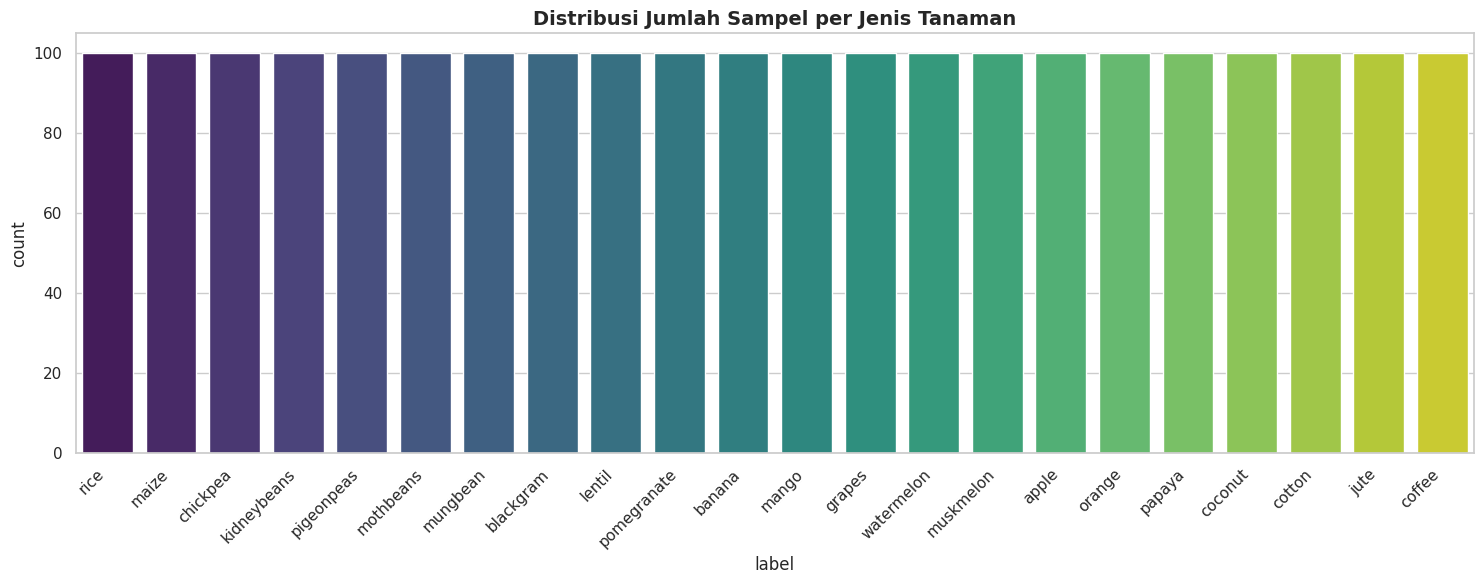

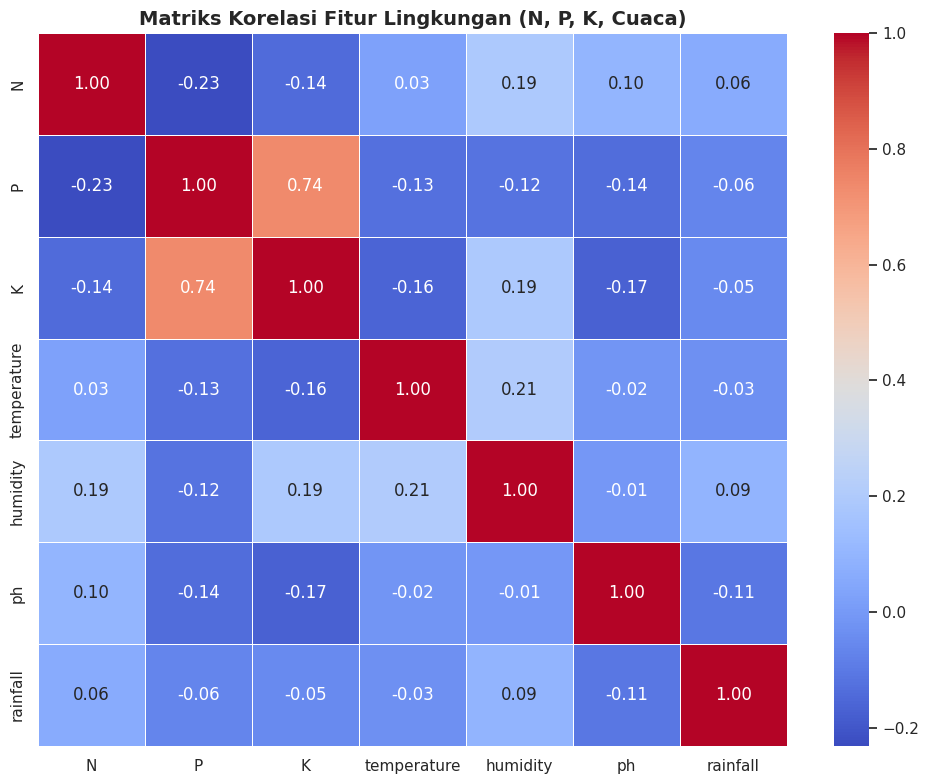

In [3]:
# ------------------------------------------------------------------------------
# STEP 3: EXPLORATORY DATA ANALYSIS (DATA UNDERSTANDING)
# ------------------------------------------------------------------------------

# 3.1 Informasi Umum Dataset dan Pengecekan Missing Values
print("\n--- Informasi Struktur Data & Missing Values ---")
print(df.info())
print("\nJumlah Missing Values per Kolom:")
print(df.isnull().sum())

# 3.2 Analisis Statistik Deskriptif
print("\n--- Statistik Deskriptif Fitur Numerik ---")
print(df.describe().T)

# 3.3 Pengecekan Distribusi Kelas Target (Label Tanaman)
print("\n--- Distribusi Kelas Target (Label Tanaman) ---")
label_counts = df['label'].value_counts()
print(label_counts)

# Visualisasi Distribusi Target
plt.figure(figsize=(15, 6))
sns.countplot(data=df, x='label', order=label_counts.index, palette='viridis')
plt.title('Distribusi Jumlah Sampel per Jenis Tanaman', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# 3.4 Matriks Korelasi Antar Fitur Lingkungan
plt.figure(figsize=(10, 8))
# Memilih kolom numerik saja untuk korelasi
corr_matrix = df.drop(columns=['label']).corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Matriks Korelasi Fitur Lingkungan (N, P, K, Cuaca)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [5]:
# ------------------------------------------------------------------------------
# STEP 5: MODELING & HYPERPARAMETER TUNING (RANDOM FOREST)
# ------------------------------------------------------------------------------

print("\n--- Memulai Proses Pemodelan (Random Forest) ---")

# 5.1 Model Baseline (Default Parameters)
rf_baseline = RandomForestClassifier(random_state=42)
rf_baseline.fit(X_train_scaled, y_train)
y_pred_base = rf_baseline.predict(X_test_scaled)
base_acc = accuracy_score(y_test, y_pred_base)
print(f"Akurasi Model Baseline: {base_acc * 100:.2f}%")

# 5.2 Eksplorasi Poin Plus: Hyperparameter Tuning menggunakan GridSearchCV
# Kita mencoba mencari kombinasi n_estimators dan max_depth terbaik
param_grid = {
    'n_estimators': [50, 100, 150],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5]
}

print("\nMelakukan Grid Search untuk mencari Hyperparameter terbaik (Mohon tunggu)...")
grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=3, # 3-Fold Cross Validation
    n_jobs=-1,
    verbose=1
)
grid_search.fit(X_train_scaled, y_train)

# Menampilkan parameter terbaik hasil tuning
best_rf_model = grid_search.best_estimator_
print(f"\nHyperparameter Terbaik: {grid_search.best_params_}")


--- Memulai Proses Pemodelan (Random Forest) ---
Akurasi Model Baseline: 99.55%

Melakukan Grid Search untuk mencari Hyperparameter terbaik (Mohon tunggu)...
Fitting 3 folds for each of 18 candidates, totalling 54 fits

Hyperparameter Terbaik: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 150}



================ EVALUASI MODEL AKHIR ================
Akurasi Akhir Model Setelah Tuning: 99.32%

--- Classification Report Komprehensif ---
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        20
      banana       1.00      1.00      1.00        20
   blackgram       1.00      0.95      0.97        20
    chickpea       1.00      1.00      1.00        20
     coconut       1.00      1.00      1.00        20
      coffee       1.00      1.00      1.00        20
      cotton       1.00      1.00      1.00        20
      grapes       1.00      1.00      1.00        20
        jute       0.95      1.00      0.98        20
 kidneybeans       1.00      1.00      1.00        20
      lentil       1.00      0.95      0.97        20
       maize       0.95      1.00      0.98        20
       mango       1.00      1.00      1.00        20
   mothbeans       0.95      1.00      0.98        20
    mungbean       1.00      1.00      1.00   

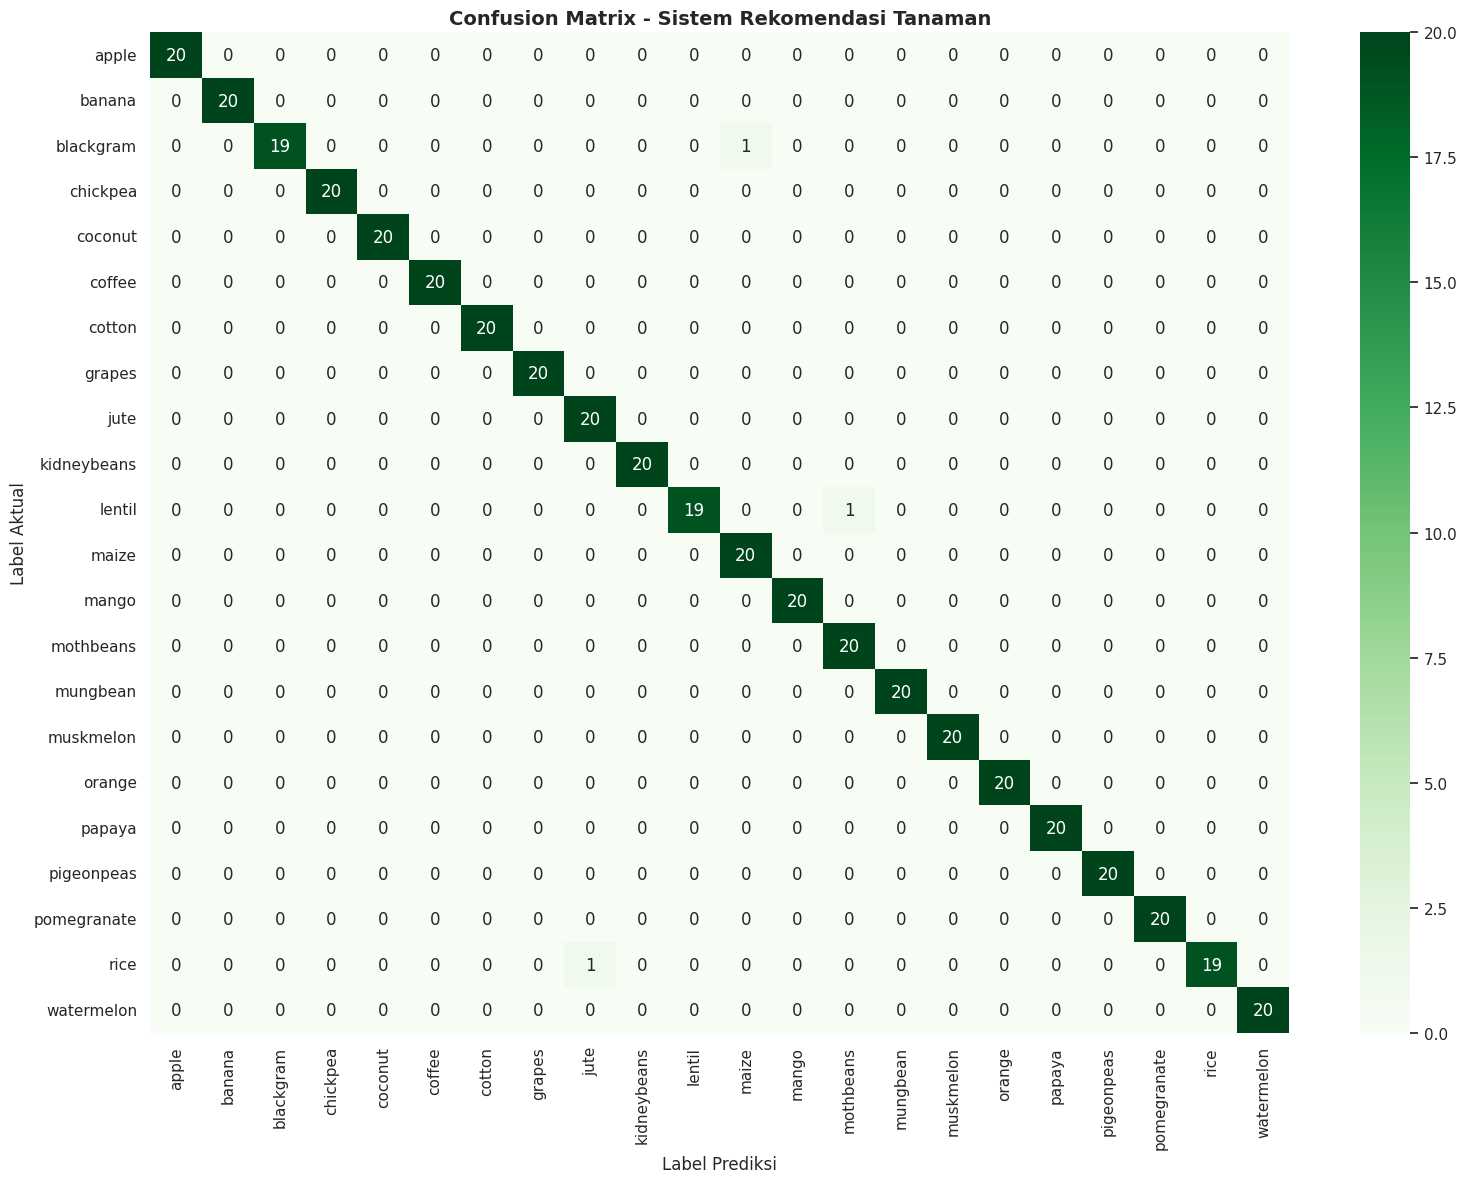

/tmp/ipykernel_4006/310759091.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances[indices], y=features[indices], palette='mako')


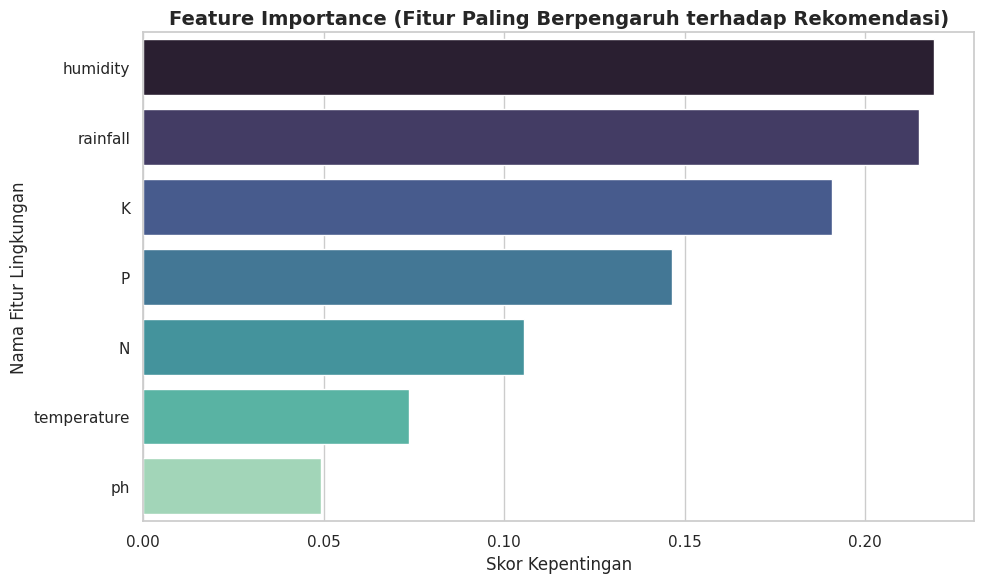

In [6]:
# ------------------------------------------------------------------------------
# STEP 6: EVALUATION (EVALUASI MODEL)
# ------------------------------------------------------------------------------

# 6.1 Prediksi Menggunakan Model Terbaik
y_pred_best = best_rf_model.predict(X_test_scaled)
final_acc = accuracy_score(y_test, y_pred_best)

print("\n================ EVALUASI MODEL AKHIR ================")
print(f"Akurasi Akhir Model Setelah Tuning: {final_acc * 100:.2f}%")
print("======================================================")

# 6.2 Classification Report (Precision, Recall, F1-Score per Kelas)
print("\n--- Classification Report Komprehensif ---")
print(classification_report(y_test, y_pred_best))

# 6.3 Visualisasi Confusion Matrix
plt.figure(figsize=(16, 12))
cm = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=best_rf_model.classes_,
            yticklabels=best_rf_model.classes_)
plt.title('Confusion Matrix - Sistem Rekomendasi Tanaman', fontsize=14, fontweight='bold')
plt.xlabel('Label Prediksi', fontsize=12)
plt.ylabel('Label Aktual', fontsize=12)
plt.tight_layout()
plt.show()

# 6.4 Analisis Fitur Paling Berpengaruh (Feature Importance)
importances = best_rf_model.feature_importances_
features = X.columns
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 6))
sns.barplot(x=importances[indices], y=features[indices], palette='mako')
plt.title('Feature Importance (Fitur Paling Berpengaruh terhadap Rekomendasi)', fontsize=14, fontweight='bold')
plt.xlabel('Skor Kepentingan', fontsize=12)
plt.ylabel('Nama Fitur Lingkungan', fontsize=12)
plt.tight_layout()
plt.show()

In [7]:
import pickle

# Menyimpan model terbaik hasil tuning
with open('model_rf.pkl', 'wb') as model_file:
    pickle.dump(best_rf_model, model_file)

# Menyimpan scaler agar input user di Hugging Face nanti di-scale dengan cara yang sama
with open('scaler.pkl', 'wb') as scaler_file:
    pickle.dump(scaler, scaler_file)

print("File model_rf.pkl dan scaler.pkl berhasil disimpan! Silakan unduh kedua file ini.")

File model_rf.pkl dan scaler.pkl berhasil disimpan! Silakan unduh kedua file ini.
